# Assignment 2: Milestone I — Natural Language Processing
## Tasks 2 & 3: Feature Representations and Review Classification
#### Student Name: XXXX XXXX
#### Student ID: 000000
#
**Environment:** Python 3.10+ | Jupyter Notebook
#
**Libraries used:**
| Library | Purpose |
|---|---|
| `os` | File existence checks |
| `collections.Counter` | Efficient word-frequency counting |
| `matplotlib.pyplot` | Class distribution and metric bar-chart visualisations |
| `numpy` | Dense vector arithmetic and array concatenation |
| `pandas` | Dataset loading, tabular manipulation, results aggregation |
| `scipy.sparse` | `csr_matrix` for sparse BoW; `hstack` for sparse concatenation |
| `sklearn.feature_extraction.text` | `CountVectorizer` (BoW), `TfidfVectorizer` (TF-IDF weights) |
| `sklearn.linear_model` | Logistic Regression classifier |
| `sklearn.model_selection` | `StratifiedKFold`, `cross_validate` (5-fold CV) |
| `sklearn.pipeline` | `Pipeline` for chaining imputer → scaler / encoder steps |
| `sklearn.compose` | `ColumnTransformer` for numeric + categorical feature fusion |
| `sklearn.preprocessing` | `StandardScaler` (numeric), `OneHotEncoder` (brand) |
| `sklearn.impute` | `SimpleImputer` for missing numeric and categorical values |
| `IPython.display` | Formatted DataFrame rendering in Jupyter |
| `imblearn.over_sampling` | `SMOTE` for synthetic minority over-sampling |
#
---
## Introduction
#
This notebook covers **Tasks 2 and 3** of Assignment 2, working with the cosmetics
and beauty product reviews dataset.
#
**Task 2 — Feature Representations** converts pre-processed review text from
`processed.csv` into three numeric representations consumed by the classifier:
#
* **Bag-of-Words (BoW):** Sparse unigram frequency vectors anchored to the
  vocabulary produced in Task 1 (`vocab.txt`).
* **Unweighted GloVe Embeddings:** Dense 300-d vectors formed by averaging the
  pre-trained GloVe word embeddings of every token in a review.
* **TF-IDF Weighted GloVe Embeddings:** Dense 300-d vectors formed by computing a
  TF-IDF–weighted average of GloVe embeddings, down-weighting high-frequency,
  low-information tokens so that rarer, topic-specific words carry more influence.
#
**Task 3 — Classification** evaluates Logistic Regression across the three
representations above and addresses two research questions:
#
* **Q1:** Which feature representation (BoW, Unweighted GloVe, Weighted GloVe)
  achieves the highest predictive performance on the binary `is_a_buyer` label?
* **Q2:** Does augmenting the review body with additional context — review title,
  price, rating count, and brand — improve classification accuracy?
#
All experiments use 5-fold Stratified Cross-Validation. Class distribution is
visualised upfront given the imbalanced nature of the `is_a_buyer` label.


---
## Importing Libraries


In [359]:
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse import csr_matrix, hstack as sp_hstack
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE


---
## Global Configuration
#
All file paths and hyper-parameters are declared here so they can be changed in one
place without hunting through the notebook.


In [360]:
# --- Paths ---
PROCESSED_PATH  = "processed.csv"          # Pre-processed reviews (Task 1 output)
VOCAB_PATH      = "vocab.txt"              # Vocabulary with word:index mapping (Task 1 output)
GLOVE_PATH      = "glove.6B.300d.txt"     # Pre-trained GloVe 300-d embeddings
COUNT_VEC_PATH  = "count_vectors.txt"     # Task 2a output: sparse BoW vectors
UNWEIGHTED_PATH = "unweighted_vectors.txt" # Task 2b output: unweighted GloVe vectors
WEIGHTED_PATH   = "weighted_vectors.txt"  # Task 2b output: TF-IDF weighted GloVe vectors

# --- Hyper-parameters ---
EMBEDDING_DIM = 300   # GloVe vector dimension
RANDOM_STATE  = 42    # Global seed for reproducibility


---
## Task 2 — Generating Feature Representations
#
Three output files are produced, each using the same line format:
#
| File | Type | Line format |
|---|---|---|
| `count_vectors.txt` | Sparse BoW | `#idx,word_idx:freq,...` |
| `unweighted_vectors.txt` | Dense 300-d | `#idx,v0,v1,...,v299` |
| `weighted_vectors.txt` | Dense 300-d | `#idx,v0,v1,...,v299` |


### Task 2a — Bag-of-Words Count Vectors
#
Each review is serialised as a sparse vector that records the frequency of every
vocabulary word it contains.  Words absent from `vocab.txt` are ignored, keeping the
output compact.  Entries within each line are sorted by word index for stable output.


#### Load Vocabulary


In [361]:
word2idx: dict[str, int] = {}

with open(VOCAB_PATH, "r", encoding="utf-8") as _f:
    for _line in _f:
        _line = _line.strip()
        if not _line:
            continue
        # vocab.txt format produced by Task 1: word:index
        _word, _idx = _line.rsplit(":", 1)
        word2idx[_word] = int(_idx)

print(f"Vocabulary size  : {len(word2idx):,}")
print(f"First 10 entries : {list(word2idx.items())[:10]}")


Vocabulary size  : 7,241
First 10 entries : [('aa', 0), ('aback', 1), ('abd', 2), ('abh', 3), ('ability', 4), ('abit', 5), ('abnormally', 6), ('abroad', 7), ('abs', 8), ('absent', 9)]


#### Load Pre-processed Reviews


In [362]:
df_task2 = pd.read_csv(PROCESSED_PATH)

# Normalise is_a_buyer to int (0/1) once; handles bool, "TRUE"/"FALSE", "True"/"False"
df_task2["is_a_buyer"] = (
    df_task2["is_a_buyer"]
    .astype(str).str.strip().str.upper()
    .map({"TRUE": 1, "FALSE": 0})
)

reviews: list[str] = df_task2["review_text"].fillna("").astype(str).tolist()

print(f"Reviews loaded        : {len(reviews):,}")
print(f"Example (first 200 ch): {reviews[0][:200]}")


Reviews loaded        : 59,832
Example (first 200 ch): work claim difference day olay cleanser result


#### Build and Save Count Vectors


In [363]:
def to_sparse_count_line(review_idx: int, review_text: str, w2i: dict) -> str:
    """Serialise one review as a sparse count-vector line.

    Format: #<review_idx>,<word_idx>:<freq>,...
    """
    tokens = review_text.split() if review_text else []
    freq   = Counter(tok for tok in tokens if tok in w2i)
    pairs  = sorted((w2i[word], cnt) for word, cnt in freq.items())

    if not pairs:
        return f"#{review_idx},"

    return f"#{review_idx}," + ",".join(f"{idx}:{cnt}" for idx, cnt in pairs)


count_vector_lines = [
    to_sparse_count_line(i, text, word2idx) for i, text in enumerate(reviews)
]

with open(COUNT_VEC_PATH, "w", encoding="utf-8") as _f:
    _f.write("\n".join(count_vector_lines))

print(f"count_vectors.txt — {len(count_vector_lines):,} lines written")
print("Preview (first 3 lines, truncated to 200 chars):")
for _line in count_vector_lines[:3]:
    print(f"  {_line[:200]}")


count_vectors.txt — 59,832 lines written
Preview (first 3 lines, truncated to 200 chars):
  #0,1022:1,1041:1,1521:1,1674:1,4354:1,5309:1,7133:1
  #1,1022:1,5862:1,5902:1,6456:1
  #2,15:1,1153:1,2722:1,4028:1,4046:1,4344:1,5075:1,7091:1,7133:1


### Task 2b — GloVe Embedding Vectors
#
Pre-trained GloVe embeddings (`glove.6B.300d.txt`) encode semantic relationships
learned from a large external corpus into 300-dimensional vectors.  Two aggregation
strategies are implemented:
#
| Strategy | Description |
|---|---|
| **Unweighted average** | All in-vocabulary tokens contribute equally |
| **TF-IDF weighted average** | Rare, informative tokens receive higher weight |
#
Reviews with no GloVe-covered tokens are represented as zero vectors.


#### Tokenisation Helper


In [364]:
def tokenize(text: str) -> list[str]:
    """Split pre-processed review text into tokens.

    processed.csv already contains clean, lowercased, space-separated tokens
    produced by Task 1, so a plain split is correct and consistent with the
    count-vector tokeniser.
    """
    return text.split() if text else []


#### Load GloVe Embeddings


In [365]:
def load_glove(file_path: str) -> dict[str, np.ndarray]:
    """Parse a GloVe text file into a word → vector dictionary."""
    embeddings: dict[str, np.ndarray] = {}
    with open(file_path, encoding="utf-8") as _f:
        for _line in _f:
            _values = _line.split()
            embeddings[_values[0]] = np.asarray(_values[1:], dtype="float32")
    return embeddings


glove = load_glove(GLOVE_PATH)
print(f"GloVe vocabulary : {len(glove):,} words  |  dimension: {EMBEDDING_DIM}")


GloVe vocabulary : 400,001 words  |  dimension: 300


#### Build and Save Unweighted Embedding Vectors


In [366]:
unweighted_vectors: list[str] = []

for _i, _review in enumerate(reviews):
    _tokens  = tokenize(_review)
    _vecs    = [glove[w] for w in _tokens if w in glove]
    _avg_vec = np.mean(_vecs, axis=0) if _vecs else np.zeros(EMBEDDING_DIM)
    unweighted_vectors.append(f"#{_i}," + ",".join(map(str, _avg_vec)))

with open(UNWEIGHTED_PATH, "w", encoding="utf-8") as _f:
    _f.write("\n".join(unweighted_vectors) + "\n")

print(f"unweighted_vectors.txt — {len(unweighted_vectors):,} lines written")
print("\nPreview — first 3 reviews:")
for _i in range(3):
    _tokens = tokenize(reviews[_i])
    _in_glove = [w for w in _tokens if w in glove]
    print(f"\n  Review #{_i}")
    print(f"  Original text : {reviews[_i][:200]}")
    print(f"  Tokens        : {_tokens[:15]}{'...' if len(_tokens) > 15 else ''}")
    print(f"  In GloVe      : {len(_in_glove)}/{len(_tokens)} tokens")
    print(f"  Full vector   : {unweighted_vectors[_i]}")


unweighted_vectors.txt — 59,832 lines written

Preview — first 3 reviews:

  Review #0
  Original text : work claim difference day olay cleanser result
  Tokens        : ['work', 'claim', 'difference', 'day', 'olay', 'cleanser', 'result']
  In GloVe      : 7/7 tokens
  Full vector   : #0,0.14781442,0.2877383,-0.06825671,0.116026424,-0.29140028,-0.09207285,-0.101884425,0.005842856,0.036033135,-1.06034,-0.032156426,-0.010611714,-0.08491143,0.13720787,0.021288285,0.033463996,0.24081056,0.19038545,-0.18002507,-0.10613428,0.11629815,-0.11208386,-0.046770215,-0.06421204,-0.061840426,0.021769,-0.0053159976,-0.026971718,-0.008572428,-0.019548574,-0.06994857,0.23698129,-0.25249714,0.022847,-0.4077329,0.18237886,-0.10310287,0.047202658,0.0129984245,0.07488929,0.029613137,-0.10714986,0.010334858,-0.2802237,-0.067996,0.07201171,0.19647285,0.2170063,-0.011158558,-0.14335142,0.013999283,-0.08738486,0.20685856,0.22552584,-0.17585143,0.2791566,-0.030603006,0.107269,0.14125058,0.18487571,0.20359485,0.0

#### Build and Save TF-IDF Weighted Embedding Vectors
#
**Step 1** — Fit a TF-IDF vectorizer on all reviews to learn corpus-wide term
weights.  The same custom tokenizer is used so the vocabulary matches GloVe look-ups.


In [367]:
_tfidf_vectorizer = TfidfVectorizer(tokenizer=tokenize, token_pattern=None, lowercase=True)
tfidf_matrix      = _tfidf_vectorizer.fit_transform(reviews)
word_tfidf_index  = {w: i for i, w in enumerate(_tfidf_vectorizer.get_feature_names_out())}

print(f"TF-IDF vocabulary size : {len(word_tfidf_index):,}")


TF-IDF vocabulary size : 7,241


**Step 2** — For each review, compute the TF-IDF–weighted average of its token
embeddings, then normalise by the total weight to remove length bias.


In [368]:
weighted_vectors: list[str] = []

for _i, _review in enumerate(reviews):
    _tokens       = tokenize(_review)
    _vec          = np.zeros(EMBEDDING_DIM)
    _total_weight = 0.0

    for _word in _tokens:
        if _word in glove and _word in word_tfidf_index:
            _w             = tfidf_matrix[_i, word_tfidf_index[_word]]
            _vec          += glove[_word] * _w
            _total_weight += _w

    if _total_weight > 0:
        _vec /= _total_weight

    weighted_vectors.append(f"#{_i}," + ",".join(map(str, _vec)))

with open(WEIGHTED_PATH, "w", encoding="utf-8") as _f:
    _f.write("\n".join(weighted_vectors) + "\n")

print(f"weighted_vectors.txt — {len(weighted_vectors):,} lines written")
print("\nPreview — first 3 reviews:")
for _i in range(3):
    _tokens = tokenize(reviews[_i])
    _in_both = [w for w in _tokens if w in glove and w in word_tfidf_index]
    print(f"\n  Review #{_i}")
    print(f"  Original text    : {reviews[_i][:200]}")
    print(f"  Tokens           : {_tokens[:15]}{'...' if len(_tokens) > 15 else ''}")
    print(f"  In GloVe+TF-IDF  : {len(_in_both)}/{len(_tokens)} tokens")
    print(f"  Full vector      : {weighted_vectors[_i]}")


weighted_vectors.txt — 59,832 lines written

Preview — first 3 reviews:

  Review #0
  Original text    : work claim difference day olay cleanser result
  Tokens           : ['work', 'claim', 'difference', 'day', 'olay', 'cleanser', 'result']
  In GloVe+TF-IDF  : 7/7 tokens
  Full vector      : #0,0.15686052531945463,0.28816836971531107,-0.03510490356709765,0.12740175568345571,-0.322838141292191,-0.08980469273455524,-0.08778500396486405,0.011469963589091754,0.0668724272333774,-0.8418024324305212,-0.048013546099344336,0.00609471531958887,-0.08720460566974654,0.12527758335593997,0.011310658335070238,0.07423833090905835,0.2849457776676935,0.25600794768858176,-0.1551502332615184,-0.14320977269378715,0.15551695168878102,-0.13286319263200133,-0.08217628089537629,-0.06378957589078696,-0.09255122951900158,0.016159658363703432,-0.04518300901674045,0.0022742365553026058,0.010108076175321012,-0.033209948425676615,-0.1453915676266935,0.19773035570791528,-0.2239583296087972,-0.0009424791524311299,-

#### Validator — Original Text vs Unweighted vs Weighted Vectors
#
Each stored line is a formatted string `#idx,v0,v1,...`.  We parse both vectors
back to numpy arrays so we can compare them numerically.  Unweighted and weighted
vectors represent the same review but must **not** be identical — TF-IDF weighting
shifts the average toward rarer, more informative tokens.


In [369]:
def _parse_vec_line(line: str) -> np.ndarray:
    """Parse '#idx,v0,v1,...' back to a numpy array (drops the index)."""
    parts = line.split(",")
    return np.array([float(v) for v in parts[1:]], dtype=float)


def validator_embedding(review_idx, review_txts, tokenised, unweighted_lines, weighted_lines, n_dims=10):
    u_vec = _parse_vec_line(unweighted_lines[review_idx])
    w_vec = _parse_vec_line(weighted_lines[review_idx])

    u_preview = ",".join(f"{v:.6f}" for v in u_vec[:n_dims])
    w_preview = ",".join(f"{v:.6f}" for v in w_vec[:n_dims])

    norm_u = np.linalg.norm(u_vec)
    norm_w = np.linalg.norm(w_vec)
    cosine = (
        np.dot(u_vec, w_vec) / (norm_u * norm_w)
        if norm_u > 0 and norm_w > 0 else float("nan")
    )

    print("=" * 60)
    print(f"Review #{review_idx}")
    print(f"Original text : {review_txts[review_idx][:200]}")
    print(f"Tokens        : {tokenised[review_idx][:12]}")
    print("-" * 60)
    print(f"Unweighted (first {n_dims} of {len(u_vec)} dims):")
    print(f"  #{review_idx},{u_preview},...")
    print(f"Weighted   (first {n_dims} of {len(w_vec)} dims):")
    print(f"  #{review_idx},{w_preview},...")
    print("-" * 60)
    print(f"Unweighted norm : {norm_u:.4f}")
    print(f"Weighted norm   : {norm_w:.4f}")
    print(f"Cosine similarity (u vs w) : {cosine:.4f}  (expected < 1.0)")
    print(f"Vectors identical          : {np.allclose(u_vec, w_vec)}  (expected False)")
    print("=" * 60)
    print()


tokenised_for_display = df_task2["review_text"].fillna("").astype(str).apply(str.split).tolist()

for _test_idx in range(3):
    validator_embedding(_test_idx, reviews, tokenised_for_display, unweighted_vectors, weighted_vectors)


Review #0
Original text : work claim difference day olay cleanser result
Tokens        : ['work', 'claim', 'difference', 'day', 'olay', 'cleanser', 'result']
------------------------------------------------------------
Unweighted (first 10 of 300 dims):
  #0,0.147814,0.287738,-0.068257,0.116026,-0.291400,-0.092073,-0.101884,0.005843,0.036033,-1.060340,...
Weighted   (first 10 of 300 dims):
  #0,0.156861,0.288168,-0.035105,0.127402,-0.322838,-0.089805,-0.087785,0.011470,0.066872,-0.841802,...
------------------------------------------------------------
Unweighted norm : 2.7869
Weighted norm   : 2.8049
Cosine similarity (u vs w) : 0.9568  (expected < 1.0)
Vectors identical          : False  (expected False)

Review #1
Original text : claim thing smoothens soft
Tokens        : ['claim', 'thing', 'smoothens', 'soft']
------------------------------------------------------------
Unweighted (first 10 of 300 dims):
  #1,0.283904,0.188220,-0.126521,0.032296,-0.133820,-0.259465,0.213442,0.145920

---
## Task 3 — Clothing Review Classification
#
Using the three representations generated above, we train and evaluate a Logistic
Regression classifier to predict `is_a_buyer` — whether a reviewer purchased the product.


### Shared I/O Utilities
#
These parsing functions are shared across Q1 and Q2.  `align_to_dataframe` reorders
a loaded matrix to match the sequential row order of a DataFrame, preventing
index–label mismatches when doc indices are out of order.


In [370]:
def load_count_vectors(path: str) -> tuple:
    """Parse a sparse count-vector file into a CSR matrix.

    Returns (csr_matrix, doc_indices_array) or (None, None) on empty file.
    """
    doc_indices: list[int] = []
    rows, cols, data = [], [], []
    max_col = -1

    with open(path, "r", encoding="utf-8") as _f:
        for _row_id, _line in enumerate(_f):
            _line = _line.strip()
            if not _line:
                continue
            _parts  = _line.split(",")
            _doc_id = int(_parts[0].lstrip("#"))
            doc_indices.append(_doc_id)

            for _item in _parts[1:]:
                if not _item or ":" not in _item:
                    continue
                _c, _v = _item.split(":")
                _c, _v = int(_c), float(_v)
                rows.append(_row_id)
                cols.append(_c)
                data.append(_v)
                max_col = max(max_col, _c)

    if not doc_indices:
        return None, None

    X = csr_matrix((data, (rows, cols)), shape=(len(doc_indices), max_col + 1))
    return X, np.array(doc_indices)


def load_dense_vectors(path: str) -> tuple:
    """Parse a dense embedding file into a NumPy array.

    Returns (np.ndarray, doc_indices_array) or (None, None) on empty file.
    """
    doc_indices: list[int] = []
    vectors: list[list[float]] = []

    with open(path, "r", encoding="utf-8") as _f:
        for _line in _f:
            _line = _line.strip()
            if not _line:
                continue
            _parts = _line.split(",")
            doc_indices.append(int(_parts[0].lstrip("#")))
            vectors.append([float(x) for x in _parts[1:] if x.strip()])

    if not doc_indices:
        return None, None

    return np.array(vectors, dtype=float), np.array(doc_indices)


def align_to_dataframe(X, doc_indices: np.ndarray, n_rows: int):
    """Reorder X rows to match sequential DataFrame indices 0…n-1."""
    if X is None or doc_indices is None:
        return None
    if len(doc_indices) != n_rows:
        raise ValueError(
            f"Vector file has {len(doc_indices)} rows but DataFrame has {n_rows} rows."
        )
    order = np.argsort(doc_indices)
    return X[order] if hasattr(X, "tocsr") else X[order, :]


---
### Q1 — Language Model Comparison
#
**Objective:** Determine which feature representation achieves the best
`is_a_buyer` classification performance using Logistic Regression.
#
**Representations evaluated:** Bag-of-Words · Unweighted GloVe · TF-IDF Weighted GloVe
#
**Classifier:** Logistic Regression
#
**Method:** 5-fold Stratified Cross-Validation reporting mean ± std Accuracy,
Precision, Recall, and F1.


#### Load Dataset and Prepare Labels


In [371]:
# Load each vector file into a DataFrame and attach the corresponding is_a_buyer label.
# The #idx field in every vector line is the 0-based row position in processed.csv,
# so df_task2.loc[idx, "is_a_buyer"] gives the exact label for each vector row.
X_count,      idx_count      = load_count_vectors(COUNT_VEC_PATH)
X_unweighted, idx_unweighted = load_dense_vectors(UNWEIGHTED_PATH)
X_weighted,   idx_weighted   = load_dense_vectors(WEIGHTED_PATH)

df_count = pd.DataFrame.sparse.from_spmatrix(
    X_count,
    index=idx_count,
    columns=[f"w{i}" for i in range(X_count.shape[1])],
)
df_count["is_a_buyer"] = df_task2.loc[idx_count, "is_a_buyer"].to_numpy()

df_unweighted = pd.DataFrame(
    X_unweighted,
    index=idx_unweighted,
    columns=[f"dim_{i}" for i in range(X_unweighted.shape[1])],
)
df_unweighted["is_a_buyer"] = df_task2.loc[idx_unweighted, "is_a_buyer"].to_numpy()

df_weighted = pd.DataFrame(
    X_weighted,
    index=idx_weighted,
    columns=[f"dim_{i}" for i in range(X_weighted.shape[1])],
)
df_weighted["is_a_buyer"] = df_task2.loc[idx_weighted, "is_a_buyer"].to_numpy()

print(f"\ndf_count      : {df_count.shape}  - is_a_buyer sample: {df_count['is_a_buyer'].iloc[:3].tolist()}")
print(f"df_unweighted : {df_unweighted.shape}  - is_a_buyer sample: {df_unweighted['is_a_buyer'].iloc[:3].tolist()}")
print(f"df_weighted   : {df_weighted.shape}  - is_a_buyer sample: {df_weighted['is_a_buyer'].iloc[:3].tolist()}")



df_count      : (59832, 7242)  - is_a_buyer sample: [1, 1, 1]
df_unweighted : (59832, 301)  - is_a_buyer sample: [1, 1, 1]
df_weighted   : (59832, 301)  - is_a_buyer sample: [1, 1, 1]


#### Class Distribution


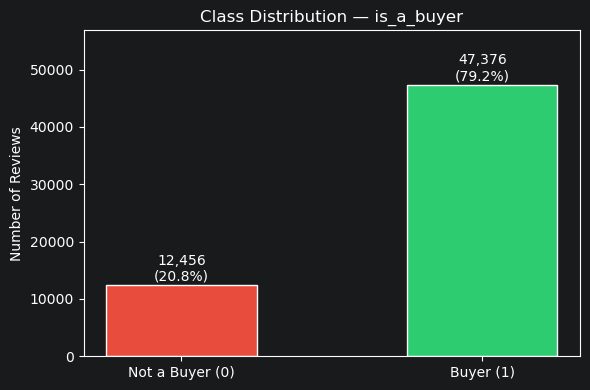

Imbalance ratio : 3.80x  (majority class: Buyer)


In [372]:
# df_task2["is_a_buyer"] is already {0, 1} after load-time normalisation
_class_counts  = df_task2["is_a_buyer"].value_counts().sort_index()   # index: 0, 1
_cls_labels    = ["Not a Buyer (0)", "Buyer (1)"]
_cls_colors    = ["#e74c3c", "#2ecc71"]

fig, ax = plt.subplots(figsize=(6, 4))
_bars = ax.bar(_cls_labels, _class_counts.values, color=_cls_colors,
               edgecolor="white", width=0.5)
for _bar, _cnt in zip(_bars, _class_counts.values):
    ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 200,
            f"{_cnt:,}\n({_cnt / len(df_task2):.1%})",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of Reviews")
ax.set_title("Class Distribution — is_a_buyer")
ax.set_ylim(0, _class_counts.max() * 1.2)
plt.tight_layout()
plt.show()

_majority_cls = "Buyer" if _class_counts.idxmax() == 1 else "Not Buyer"
print(f"Imbalance ratio : {_class_counts.max() / _class_counts.min():.2f}x  "
      f"(majority class: {_majority_cls})")


#### Cross-Validation Helper


In [373]:
def evaluate_representation(X, y, representation_name: str,
                             classifier_name: str, classifier) -> dict:
    """Run 5-fold stratified CV and return a labelled metrics dict."""
    _cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    _scoring = {"accuracy"  : "accuracy",
                "precision" : "precision_macro",
                "recall"    : "recall_macro",
                "f1"        : "f1_macro"}

    _scores = cross_validate(classifier, X, y, cv=_cv, scoring=_scoring,
                             n_jobs=-1, error_score="raise")

    # Per-fold breakdown
    print(f"\n  [{representation_name}] {classifier_name}")
    print(f"  {'Fold':<6} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'-'*6} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
    for _fold in range(5):
        print(f"  {_fold + 1:<6} "
              f"{_scores['test_accuracy'][_fold]:>10.4f} "
              f"{_scores['test_precision'][_fold]:>10.4f} "
              f"{_scores['test_recall'][_fold]:>10.4f} "
              f"{_scores['test_f1'][_fold]:>10.4f}")
    print(f"  {'Mean':<6} "
          f"{_scores['test_accuracy'].mean():>10.4f} "
          f"{_scores['test_precision'].mean():>10.4f} "
          f"{_scores['test_recall'].mean():>10.4f} "
          f"{_scores['test_f1'].mean():>10.4f}")
    print(f"  {'Std':<6} "
          f"{_scores['test_accuracy'].std():>10.4f} "
          f"{_scores['test_precision'].std():>10.4f} "
          f"{_scores['test_recall'].std():>10.4f} "
          f"{_scores['test_f1'].std():>10.4f}")

    return {
        "Representation" : representation_name,
        "Classifier"     : classifier_name,
        "Accuracy"       : f"{_scores['test_accuracy'].mean():.4f} ± {_scores['test_accuracy'].std():.4f}",
        "Precision"      : f"{_scores['test_precision'].mean():.4f} ± {_scores['test_precision'].std():.4f}",
        "Recall"         : f"{_scores['test_recall'].mean():.4f} ± {_scores['test_recall'].std():.4f}",
        "F1"             : f"{_scores['test_f1'].mean():.4f} ± {_scores['test_f1'].std():.4f}",
        "_f1_sort"       : _scores["test_f1"].mean(),
    }


def evaluate_representation_smote(X, y, representation_name: str,
                                   classifier_name: str, classifier) -> dict:
    """5-fold stratified CV: SMOTE on training fold only, test on original fold.

    Each fold explicitly:
      1. Splits into train / test using the ORIGINAL class distribution.
      2. Applies SMOTE to the TRAINING fold only → balances minority class.
      3. Trains the classifier on the SMOTE-augmented training data.
      4. Evaluates on the ORIGINAL test fold (no synthetic samples in test).

    Macro-average is used so both classes contribute equally to the metrics,
    making the minority-class improvement from SMOTE visible.
    """
    from sklearn.base import clone
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    import scipy.sparse as sp

    _cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    _smote  = SMOTE(random_state=RANDOM_STATE)

    _fold_results = []

    for _fold, (train_idx, test_idx) in enumerate(_cv.split(X, y)):
        # --- Split into original train / test folds ---
        X_train = X[train_idx] if not sp.issparse(X) else X[train_idx]
        X_test  = X[test_idx]  if not sp.issparse(X) else X[test_idx]
        y_train = y[train_idx]
        y_test  = y[test_idx]

        print(f"  Fold {_fold + 1}  |  "
              f"Train: {len(y_train):,} samples "
              f"(class 0: {(y_train==0).sum()}, class 1: {(y_train==1).sum()})  →  ", end="")

        # --- Apply SMOTE to training fold ONLY ---
        X_train_res, y_train_res = _smote.fit_resample(X_train, y_train)

        print(f"after SMOTE: {len(y_train_res):,} "
              f"(class 0: {(y_train_res==0).sum()}, class 1: {(y_train_res==1).sum()})")
        print(f"         |  Test : {len(y_test):,} samples  ← ORIGINAL distribution (no SMOTE)")

        # --- Train on SMOTE data, evaluate on original test fold ---
        _clf = clone(classifier)
        _clf.fit(X_train_res, y_train_res)
        y_pred = _clf.predict(X_test)

        _fold_results.append({
            "accuracy"  : accuracy_score(y_test, y_pred),
            "precision" : precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall"    : recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1"        : f1_score(y_test, y_pred, average="macro", zero_division=0),
        })

    _acc  = np.array([r["accuracy"]  for r in _fold_results])
    _prec = np.array([r["precision"] for r in _fold_results])
    _rec  = np.array([r["recall"]    for r in _fold_results])
    _f1   = np.array([r["f1"]        for r in _fold_results])

    print(f"\n  [{representation_name}] {classifier_name} + SMOTE — per-fold results")
    print(f"  {'Fold':<6} {'Accuracy':>10} {'Prec(M)':>10} {'Rec(M)':>10} {'F1(M)':>10}")
    print(f"  {'-'*6} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
    for _i, r in enumerate(_fold_results):
        print(f"  {_i+1:<6} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
              f"{r['recall']:>10.4f} {r['f1']:>10.4f}")
    print(f"  {'Mean':<6} {_acc.mean():>10.4f} {_prec.mean():>10.4f} "
          f"{_rec.mean():>10.4f} {_f1.mean():>10.4f}")
    print(f"  {'Std':<6} {_acc.std():>10.4f} {_prec.std():>10.4f} "
          f"{_rec.std():>10.4f} {_f1.std():>10.4f}")

    return {
        "Representation" : representation_name,
        "Classifier"     : classifier_name,
        "Accuracy"       : f"{_acc.mean():.4f} ± {_acc.std():.4f}",
        "Precision"      : f"{_prec.mean():.4f} ± {_prec.std():.4f}",
        "Recall"         : f"{_rec.mean():.4f} ± {_rec.std():.4f}",
        "F1"             : f"{_f1.mean():.4f} ± {_f1.std():.4f}",
        "_f1_sort"       : _f1.mean(),
    }


In [374]:
_lr_q1    = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)
q1_results = []

# Logistic Regression with count vectors
q1_results.append(evaluate_representation(X_count, df_count['is_a_buyer'],
                                          "Bag-of-Words", "Logistic Regression", _lr_q1))


  [Bag-of-Words] Logistic Regression
  Fold     Accuracy  Precision     Recall         F1
  ------ ---------- ---------- ---------- ----------
  1          0.7977     0.6807     0.5636     0.5669
  2          0.7983     0.6852     0.5597     0.5606
  3          0.7953     0.6714     0.5534     0.5513
  4          0.7974     0.6813     0.5572     0.5569
  5          0.7990     0.6868     0.5649     0.5686
  Mean       0.7975     0.6811     0.5598     0.5609
  Std        0.0012     0.0054     0.0042     0.0064


In [375]:
# Logistic Regression with unweighted GloVe vectors
q1_results.append(evaluate_representation(X_unweighted, df_unweighted['is_a_buyer'],
                                          "Unweighted GloVe", "Logistic Regression", _lr_q1))


  [Unweighted GloVe] Logistic Regression
  Fold     Accuracy  Precision     Recall         F1
  ------ ---------- ---------- ---------- ----------
  1          0.7913     0.6304     0.5069     0.4603
  2          0.7903     0.6125     0.5069     0.4614
  3          0.7906     0.6211     0.5087     0.4655
  4          0.7918     0.6473     0.5086     0.4638
  5          0.7911     0.6251     0.5065     0.4595
  Mean       0.7910     0.6273     0.5075     0.4621
  Std        0.0005     0.0116     0.0009     0.0022


In [376]:
# Logistic Regression with weighted GloVe vectors
q1_results.append(evaluate_representation(X_weighted, df_weighted['is_a_buyer'],
                                          "Weighted GloVe", "Logistic Regression", _lr_q1))



  [Weighted GloVe] Logistic Regression
  Fold     Accuracy  Precision     Recall         F1
  ------ ---------- ---------- ---------- ----------
  1          0.7919     0.6497     0.5076     0.4613
  2          0.7909     0.6263     0.5076     0.4624
  3          0.7916     0.6409     0.5083     0.4634
  4          0.7922     0.6563     0.5088     0.4640
  5          0.7907     0.6172     0.5064     0.4598
  Mean       0.7915     0.6381     0.5077     0.4622
  Std        0.0006     0.0145     0.0008     0.0015


#### Q1 — Representation Comparison Chart


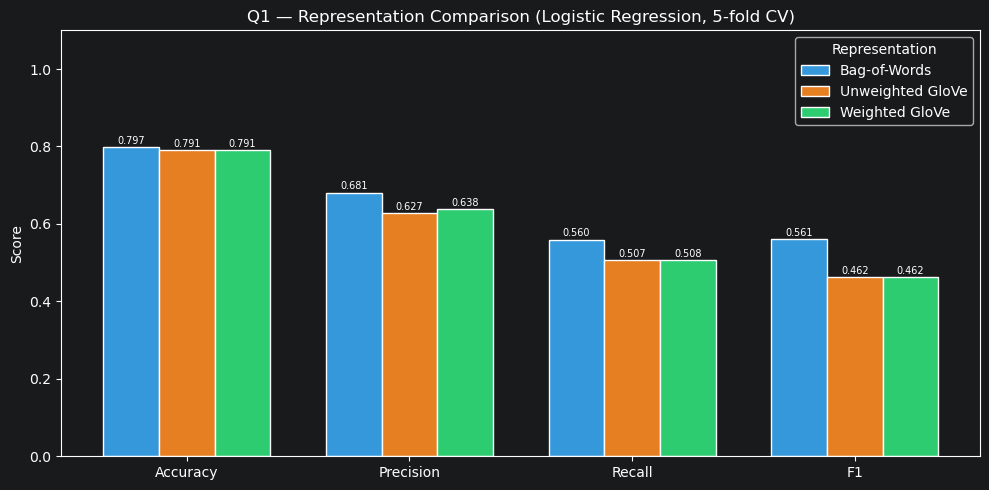

In [377]:
def _parse_mean(val: str) -> float:
    return float(val.split("±")[0].strip())

_q1_metrics = ["Accuracy", "Precision", "Recall", "F1"]
_q1_reps    = [r["Representation"] for r in q1_results]
_q1_colors  = ["#3498db", "#e67e22", "#2ecc71"]
_q1_x       = np.arange(len(_q1_metrics))
_q1_width   = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for _i, (_res, _col) in enumerate(zip(q1_results, _q1_colors)):
    _vals = [_parse_mean(_res[m]) for m in _q1_metrics]
    _bars = ax.bar(_q1_x + _i * _q1_width, _vals, _q1_width,
                   label=_res["Representation"], color=_col, edgecolor="white")
    for _bar, _val in zip(_bars, _vals):
        ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.003,
                f"{_val:.3f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(_q1_x + _q1_width)
ax.set_xticklabels(_q1_metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Q1 — Representation Comparison (Logistic Regression, 5-fold CV)")
ax.legend(title="Representation")
plt.tight_layout()
plt.show()


---
### Q2 — Does Additional Context Improve Classification?
#
**Objective:** Test whether supplementing the review body with richer contextual
signals improves `is_a_buyer` prediction accuracy.
#
**Three information scenarios are compared side-by-side:**
#
| Scenario | Input features |
|---|---|
| Text only | `review_text` (Task 2 pre-computed vectors) |
| Text + Title | `review_text` + `review_title` |
| Text + Title + Extra | above + `price`, `product_rating_count`, `brand_name` |
#
For Scenario 3, a `ColumnTransformer` pipeline scales numeric features and one-hot
encodes `brand_name` before concatenating them with the text + title vectors.
#
**Method:** Same 5-fold Stratified CV strategy as Q1 for a fair comparison.


#### Scenario 1 — Text Only (Task 2 Pre-computed Vectors) - Already Evaluated in Q1
#
| Column | BoW | Unweighted GloVe | Weighted GloVe |
|---|---|---|---|
| `review_text` | ✓ | ✓ | ✓ |
#

#### Scenario 2 — Text + Review Title
#
| Column | BoW | Unweighted GloVe | Weighted GloVe |
|---|---|---|---|
| `review_text` | ✓ | ✓ | ✓ |
| `review_title` | ✓ | ✓ | ✓ |
#

For this scenario, `review_title` is represented three ways — mirroring the Task 2
pipeline — and each title representation is concatenated with its matching text
representation before cross-validation:
#
| Combined representation | Text part | Title part | Concat |
|---|---|---|---|
| Bag-of-Words | sparse BoW (Task 2a) | sparse BoW (CountVectorizer) | `sp_hstack` |
| Unweighted GloVe | dense 300-d (Task 2b) | dense 300-d (avg GloVe) | `np.hstack` |
| Weighted GloVe | dense 300-d (Task 2b) | dense 300-d (TF-IDF × GloVe) | `np.hstack` |

In [378]:
# Build three feature representations for review_title
_titles_q2 = df_task2["review_title"].fillna("").astype(str).tolist()

# --- Title BoW ---
_title_cv   = CountVectorizer(lowercase=True, min_df=2)
X_title_bow = _title_cv.fit_transform(_titles_q2)
print(f"Title BoW        : {X_title_bow.shape}")

# --- Title Unweighted GloVe ---
_title_unw_vecs = []
for _t in _titles_q2:
    _toks = _t.lower().split()
    _vecs = [glove[w] for w in _toks if w in glove]
    _title_unw_vecs.append(np.mean(_vecs, axis=0) if _vecs else np.zeros(EMBEDDING_DIM))
X_title_unweighted = np.array(_title_unw_vecs)
print(f"Title Unweighted : {X_title_unweighted.shape}")

# --- Title TF-IDF Weighted GloVe ---
_title_tfidf_vec = TfidfVectorizer(tokenizer=lambda x: x.lower().split(),
                                   token_pattern=None)
_title_tfidf_mat = _title_tfidf_vec.fit_transform(_titles_q2)
_title_word_idx  = {w: i for i, w in enumerate(_title_tfidf_vec.get_feature_names_out())}

_title_wt_vecs = []
for _i, _t in enumerate(_titles_q2):
    _toks  = _t.lower().split()
    _vec   = np.zeros(EMBEDDING_DIM)
    _total = 0.0
    for _w in _toks:
        if _w in glove and _w in _title_word_idx:
            _wt     = _title_tfidf_mat[_i, _title_word_idx[_w]]
            _vec   += glove[_w] * _wt
            _total += _wt
    if _total > 0:
        _vec /= _total
    _title_wt_vecs.append(_vec)
X_title_weighted = np.array(_title_wt_vecs)
print(f"Title Weighted   : {X_title_weighted.shape}")


Title BoW        : (59832, 3028)
Title Unweighted : (59832, 300)
Title Weighted   : (59832, 300)


In [379]:
# Evaluate Scenario 2 — Text + Title (Logistic Regression, same as Scenario 1)
_lr_q2 = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)

q2_results = []

print("Scenario 2 — Text + Title\n")

# BoW text + BoW title (sparse + sparse)
_X_bow_q2 = sp_hstack([X_count, X_title_bow])
_res = evaluate_representation(_X_bow_q2, df_count["is_a_buyer"].to_numpy(),
                               "Bag-of-Words", "Logistic Regression", _lr_q2)
_res["Information Setting"] = "Text + Title"
q2_results.append(_res)

# Unweighted GloVe text + Unweighted GloVe title (dense + dense)
_X_unw_q2 = np.hstack([X_unweighted, X_title_unweighted])
_res = evaluate_representation(_X_unw_q2, df_unweighted["is_a_buyer"].to_numpy(),
                               "Unweighted GloVe", "Logistic Regression", _lr_q2)
_res["Information Setting"] = "Text + Title"
q2_results.append(_res)

# Weighted GloVe text + Weighted GloVe title (dense + dense)
_X_wt_q2 = np.hstack([X_weighted, X_title_weighted])
_res = evaluate_representation(_X_wt_q2, df_weighted["is_a_buyer"].to_numpy(),
                               "Weighted GloVe", "Logistic Regression", _lr_q2)
_res["Information Setting"] = "Text + Title"
q2_results.append(_res)


Scenario 2 — Text + Title


  [Bag-of-Words] Logistic Regression
  Fold     Accuracy  Precision     Recall         F1
  ------ ---------- ---------- ---------- ----------
  1          0.7965     0.6746     0.5752     0.5837
  2          0.7996     0.6863     0.5767     0.5857
  3          0.7976     0.6788     0.5727     0.5803
  4          0.8006     0.6905     0.5755     0.5840
  5          0.7978     0.6790     0.5768     0.5860
  Mean       0.7984     0.6818     0.5754     0.5840
  Std        0.0015     0.0058     0.0015     0.0020

  [Unweighted GloVe] Logistic Regression
  Fold     Accuracy  Precision     Recall         F1
  ------ ---------- ---------- ---------- ----------
  1          0.7924     0.6568     0.5171     0.4832
  2          0.7918     0.6500     0.5182     0.4862
  3          0.7917     0.6470     0.5184     0.4867
  4          0.7914     0.6435     0.5169     0.4837
  5          0.7923     0.6555     0.5173     0.4838
  Mean       0.7919     0.6506     0.5176    

#### Scenario 3 — Text + Title + Extra Metadata
#
| Column | BoW | Unweighted GloVe | Weighted GloVe |
|---|---|---|---|
| `review_text` | ✓ | ✓ | ✓ |
| `review_title` | ✓ | ✓ | ✓ |
| `price` | scaled | scaled | scaled |
| `product_rating_count` | scaled | scaled | scaled |
| `brand_name` | OHE | OHE | OHE |
#
Candidate extra columns (after dropping id columns, `product_url`, `author`,
`review_date`, and `review_text` / `review_title` already used):
#
| Column | Type |
|---|---|
| `review_rating` | numeric |
| `price` | numeric |
| `avg_product_rating` | numeric |
| `product_rating_count` | numeric |
| `brand_name` | categorical |
#
A correlation heatmap is used to identify which numeric features have a meaningful
relationship with `is_a_buyer`. `brand_name` is one-hot encoded separately.


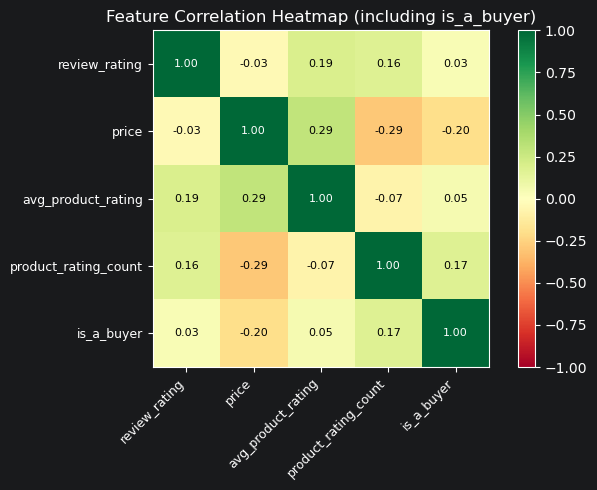

In [380]:
# --- Correlation table: numeric features vs is_a_buyer ---
_NUMERIC_EXTRA = ["review_rating", "price", "avg_product_rating", "product_rating_count"]
_CAT_EXTRA     = ["brand_name"]

df_s3 = df_task2[_NUMERIC_EXTRA + _CAT_EXTRA + ["is_a_buyer"]].copy()
_y_s3 = (df_s3["is_a_buyer"] == True).astype(int)

# Correlation matrix (numeric features + target)
_corr_full = (
    df_s3[_NUMERIC_EXTRA]
    .apply(pd.to_numeric, errors="coerce")
    .assign(is_a_buyer=_y_s3)
    .corr()
)

fig, ax = plt.subplots(figsize=(7, 5))

_heatmap_data = _corr_full.values
_labels       = _corr_full.columns.tolist()
_im = ax.imshow(_heatmap_data, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(_labels)))
ax.set_yticks(range(len(_labels)))
ax.set_xticklabels(_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(_labels, fontsize=9)
for _i in range(len(_labels)):
    for _j in range(len(_labels)):
        ax.text(_j, _i, f"{_heatmap_data[_i, _j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="black" if abs(_heatmap_data[_i, _j]) < 0.6 else "white")
plt.colorbar(_im, ax=ax)
ax.set_title("Feature Correlation Heatmap (including is_a_buyer)")

plt.tight_layout()
plt.show()


#### Observation
#
Since the target variable is `is_a_buyer`, the most relevant numerical features are
`price` and `product_rating_count`. `price` has the strongest negative correlation
with the target, while `product_rating_count` has the strongest positive correlation.
Although both relationships are weak, they provide more useful signal than
`review_rating` and `avg_product_rating`, which show near-zero correlation with
`is_a_buyer`. Based on this, only `price` and `product_rating_count` are selected
as numeric extra features, alongside `brand_name` which is one-hot encoded to
capture brand-level purchasing patterns.


In [381]:
# --- Feature selection based on heatmap observation ---
_selected_numeric = ["price", "product_rating_count"]

print("Extra features selected:")
print(f"  Numeric     : {_selected_numeric}")
print(f"  Categorical : {_CAT_EXTRA}")


Extra features selected:
  Numeric     : ['price', 'product_rating_count']
  Categorical : ['brand_name']


In [382]:
# --- Build extra feature matrix (normalize numeric, one-hot encode categorical) ---
_num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])
_cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",    OneHotEncoder(handle_unknown="ignore")),
])

_extra_ct = ColumnTransformer([
    ("num", _num_pipe, _selected_numeric),
    ("cat", _cat_pipe, _CAT_EXTRA),
], remainder="drop")

X_extra_sp = _extra_ct.fit_transform(df_s3[_selected_numeric + _CAT_EXTRA])
X_extra    = X_extra_sp.toarray()   # dense copy used only for np.hstack in GloVe scenarios

print(f"Extra feature matrix : {X_extra_sp.shape}  "
      f"({len(_selected_numeric)} numeric + OHE brand_name)")


Extra feature matrix : (59832, 13)  (2 numeric + OHE brand_name)


In [383]:
# --- Evaluate Scenario 3 — Text + Title + Extra (Logistic Regression) ---
_lr_s3 = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)

_extra_label = f"Text + Title + price + product_rating_count + brand_name"
print(f"Scenario 3 — {_extra_label}\n")

# BoW text+title (sparse) + extra (sparse)
_X_bow_s3 = sp_hstack([_X_bow_q2, X_extra_sp])
_res = evaluate_representation(_X_bow_s3, df_count["is_a_buyer"].to_numpy(),
                               "Bag-of-Words", "Logistic Regression", _lr_s3)
_res["Information Setting"] = _extra_label
q2_results.append(_res)

# Unweighted GloVe text+title (dense) + extra (dense)
_X_unw_s3 = np.hstack([_X_unw_q2, X_extra])
_res = evaluate_representation(_X_unw_s3, df_unweighted["is_a_buyer"].to_numpy(),
                               "Unweighted GloVe", "Logistic Regression", _lr_s3)
_res["Information Setting"] = _extra_label
q2_results.append(_res)

# Weighted GloVe text+title (dense) + extra (dense)
_X_wt_s3 = np.hstack([_X_wt_q2, X_extra])
_res = evaluate_representation(_X_wt_s3, df_weighted["is_a_buyer"].to_numpy(),
                               "Weighted GloVe", "Logistic Regression", _lr_s3)
_res["Information Setting"] = _extra_label
q2_results.append(_res)


Scenario 3 — Text + Title + price + product_rating_count + brand_name


  [Bag-of-Words] Logistic Regression
  Fold     Accuracy  Precision     Recall         F1
  ------ ---------- ---------- ---------- ----------
  1          0.8126     0.7151     0.6363     0.6571
  2          0.8090     0.7066     0.6320     0.6516
  3          0.8095     0.7083     0.6279     0.6477
  4          0.8124     0.7167     0.6275     0.6483
  5          0.8104     0.7100     0.6323     0.6524
  Mean       0.8108     0.7114     0.6312     0.6514
  Std        0.0015     0.0039     0.0033     0.0034

  [Unweighted GloVe] Logistic Regression
  Fold     Accuracy  Precision     Recall         F1
  ------ ---------- ---------- ---------- ----------
  1          0.8046     0.6992     0.6000     0.6160
  2          0.8060     0.7038     0.6007     0.6171
  3          0.8012     0.6891     0.5925     0.6065
  4          0.8078     0.7134     0.5938     0.6088
  5          0.8022     0.6918     0.5962     0.6112
 

#### Q2 — Scenario Comparison Chart


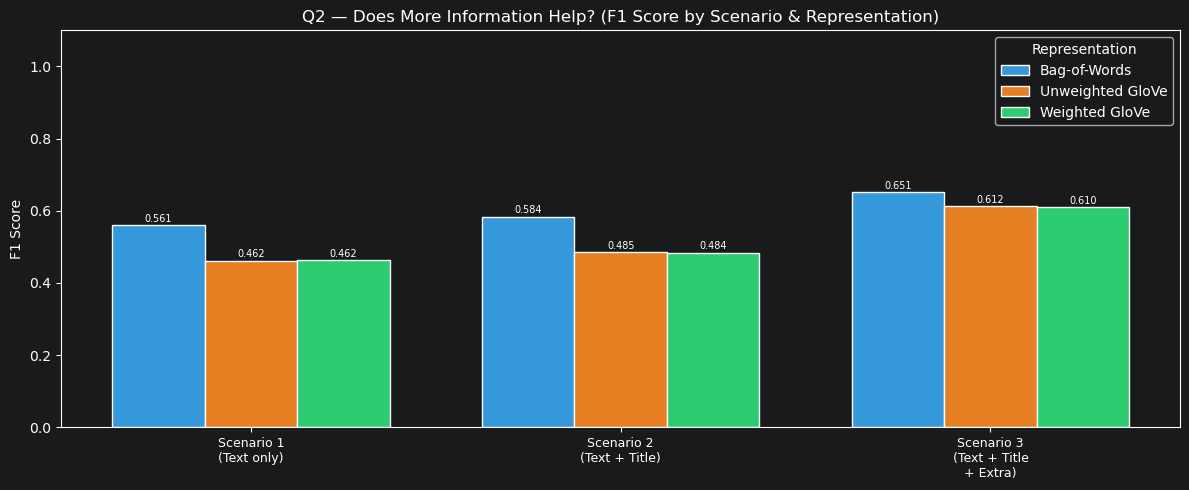

In [384]:
# Combine Scenario 1 (from Q1) with Scenario 2 & 3 for a full side-by-side view
_sc1 = [{**r, "Information Setting": "Text only"} for r in q1_results]
_all_scenarios_df = pd.DataFrame(_sc1 + q2_results)
_all_scenarios_df["_f1_mean"] = _all_scenarios_df["F1"].apply(_parse_mean)

_sc_labels  = ["Text only", "Text + Title", _extra_label]
_sc_display = ["Scenario 1\n(Text only)", "Scenario 2\n(Text + Title)",
               "Scenario 3\n(Text + Title\n+ Extra)"]
_sc_reps    = ["Bag-of-Words", "Unweighted GloVe", "Weighted GloVe"]
_sc_colors  = ["#3498db", "#e67e22", "#2ecc71"]
_sc_x       = np.arange(len(_sc_labels))
_sc_width   = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for _i, (_rep, _col) in enumerate(zip(_sc_reps, _sc_colors)):
    _vals = [
        _all_scenarios_df[
            (_all_scenarios_df["Information Setting"] == _sc) &
            (_all_scenarios_df["Representation"] == _rep)
        ]["_f1_mean"].values[0]
        for _sc in _sc_labels
    ]
    _bars = ax.bar(_sc_x + _i * _sc_width, _vals, _sc_width,
                   label=_rep, color=_col, edgecolor="white")
    for _bar, _val in zip(_bars, _vals):
        ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.003,
                f"{_val:.3f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(_sc_x + _sc_width)
ax.set_xticklabels(_sc_display, fontsize=9)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.1)
ax.set_title("Q2 — Does More Information Help? (F1 Score by Scenario & Representation)")
ax.legend(title="Representation")
plt.tight_layout()
plt.show()


---
## Data Balancing with SMOTE
#
The class distribution analysis above revealed a significant imbalance in the
`is_a_buyer` label. SMOTE (Synthetic Minority Over-sampling TEchnique) addresses
this by generating **synthetic** minority-class samples in the feature space rather
than simply duplicating existing ones, producing a more representative balanced
dataset for training.
#
SMOTE is applied independently to each of the three feature representations so that
balanced versions are ready for downstream experiments.
#

In [385]:
_y_original     = df_count["is_a_buyer"].to_numpy()
_counts_before  = pd.Series(_y_original).value_counts().sort_index()

# Fit SMOTE on BoW once — only to illustrate the balanced label distribution.
# In the classification experiments below, SMOTE is applied *inside* each CV
# training fold via ImbPipeline so validation labels are never seen by the resampler.
_, _y_smote_demo  = SMOTE(random_state=RANDOM_STATE).fit_resample(X_count, _y_original)
_counts_after = pd.Series(_y_smote_demo).value_counts().sort_index()

print(f"Original dataset size  : {len(_y_original):,}")
print(f"Resampled dataset size : {len(_y_smote_demo):,}")
print(f"\nBefore — Not a Buyer: {_counts_before[0]:,}  |  Buyer: {_counts_before[1]:,}")
print(f"After  — Not a Buyer: {_counts_after[0]:,}  |  Buyer: {_counts_after[1]:,}")


Original dataset size  : 59,832
Resampled dataset size : 94,752

Before — Not a Buyer: 12,456  |  Buyer: 47,376
After  — Not a Buyer: 47,376  |  Buyer: 47,376


#### Class Distribution Before vs After SMOTE


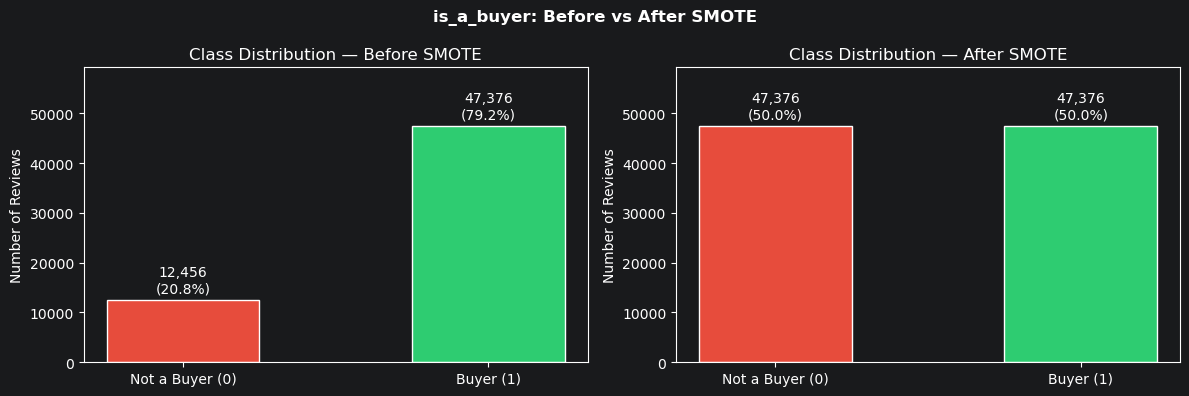

In [386]:
_cls_labels = ["Not a Buyer (0)", "Buyer (1)"]
_cls_colors = ["#e74c3c", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for _ax, _counts, _title in [
    (axes[0], _counts_before, "Before SMOTE"),
    (axes[1], _counts_after,  "After SMOTE"),
]:
    _bars = _ax.bar(_cls_labels, _counts.values, color=_cls_colors,
                    edgecolor="white", width=0.5)
    for _bar, _cnt in zip(_bars, _counts.values):
        _ax.text(
            _bar.get_x() + _bar.get_width() / 2,
            _bar.get_height() + _counts.max() * 0.02,
            f"{_cnt:,}\n({_cnt / _counts.sum():.1%})",
            ha="center", va="bottom", fontsize=10,
        )
    _ax.set_ylabel("Number of Reviews")
    _ax.set_title(f"Class Distribution — {_title}")
    _ax.set_ylim(0, _counts.max() * 1.25)

plt.suptitle("is_a_buyer: Before vs After SMOTE", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


#### Observation — SMOTE Suitability by Representation
#
SMOTE generates synthetic minority samples by interpolating linearly between a
sample and its k-nearest neighbours in the feature space.  The quality of those
synthetic samples depends entirely on how meaningful nearest-neighbour distances
are in that space:
#
| Representation | Feature space | SMOTE suitability |
|---|---|---|
| **Bag-of-Words** | Sparse, vocabulary-sized (tens of thousands of dimensions), integer counts | **Poor** — high dimensionality makes Euclidean distance unreliable (curse of dimensionality); neighbours found in such a sparse space are not semantically meaningful, so interpolated samples are likely noise |
| **Unweighted GloVe** | Dense 300-d, continuous, semantically structured | **Good** — distances are geometrically meaningful; interpolating between two similar review vectors produces a plausible synthetic representation |
| **Weighted GloVe** | Dense 300-d, continuous, rare tokens up-weighted | **Good** — same reasoning; the TF-IDF weighting makes the space slightly more discriminative, so synthetic samples capture topic-specific signals |
#
In practice this means the SMOTE results for **Bag-of-Words should be interpreted
with caution**: the classifier may appear to improve simply because the synthetic
BoW samples add spurious regularisation rather than genuine minority-class signal.
For BoW, class-weight adjustment (`LogisticRegression(class_weight="balanced")`)
is a more principled alternative that corrects imbalance without touching the data.


---
## Classification on SMOTE-Balanced Data
#
The same Q1 and Q2 experimental pipeline is repeated using SMOTE applied **inside
each CV training fold** (via `ImbPipeline`) to measure how correcting class
imbalance affects each representation and scenario.  Results are compared directly
against the baseline.  Note that BoW results should be read cautiously — see the
observation above regarding the curse of dimensionality.


#### Why Binary Scoring Breaks After SMOTE
#
The baseline experiments use **binary** precision / recall / F1 with `pos_label=1`
(Buyer — the **majority** class).  After SMOTE balances the training fold, the
classifier shifts its decision boundary and starts predicting class 0 (Not Buyer)
more often.  Evaluating that on the still-imbalanced test fold produces:
#
| Symptom | Cause |
|---|---|
| Precision ≈ majority-class base rate (~85 %) | Every positive prediction is likely right by chance — model isn't discriminating |
| Recall ≈ Accuracy (~61 %) | Model predicts 1 for only ~61 % of samples, missing ~39 % of true Buyers |
| All representations give nearly identical scores | Binary scoring is dominated by the class imbalance, not by representation quality |
#
**Fix — macro-average scoring:** weights both classes equally.  The improvement in
minority-class (Not Buyer) recall is now captured and representations can be
meaningfully distinguished.
#

### Q1 (SMOTE) — Language Model Comparison
#
**Representations evaluated:** Bag-of-Words · Unweighted GloVe · TF-IDF Weighted GloVe
#
**Classifier:** Logistic Regression — same hyper-parameters as baseline Q1
#
**Metrics:** Macro-averaged Precision, Recall, F1 (both classes weighted equally)
#
**Method:** 5-fold Stratified CV; SMOTE applied to training fold only (no leakage).


In [387]:
_lr_q1_sm     = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)
q1_sm_results = []

# Pass original (imbalanced) X — SMOTE runs inside each fold via ImbPipeline
q1_sm_results.append(evaluate_representation_smote(
    X_count, _y_original, "Bag-of-Words", "Logistic Regression", _lr_q1_sm))
q1_sm_results.append(evaluate_representation_smote(
    X_unweighted, df_unweighted["is_a_buyer"].to_numpy(),
    "Unweighted GloVe", "Logistic Regression", _lr_q1_sm))
q1_sm_results.append(evaluate_representation_smote(
    X_weighted, df_weighted["is_a_buyer"].to_numpy(),
    "Weighted GloVe", "Logistic Regression", _lr_q1_sm))


  Fold 1  |  Train: 47,865 samples (class 0: 9965, class 1: 37900)  →  after SMOTE: 75,800 (class 0: 37900, class 1: 37900)
         |  Test : 11,967 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 2  |  Train: 47,865 samples (class 0: 9964, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,967 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 3  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 4  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 5  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SMOTE)

  [Bag-of-Words] Logistic Reg

#### Q1 (SMOTE) — Representation Comparison Chart


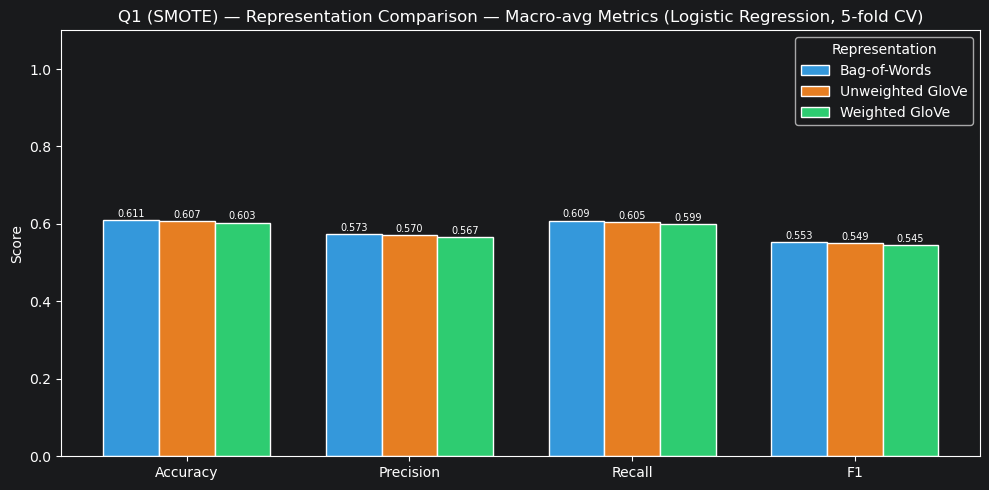

In [388]:
_q1_x     = np.arange(len(_q1_metrics))
_q1_width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for _i, (_res, _col) in enumerate(zip(q1_sm_results, _sc_colors)):
    _vals = [_parse_mean(_res[m]) for m in _q1_metrics]
    _bars = ax.bar(_q1_x + _i * _q1_width, _vals, _q1_width,
                   label=_res["Representation"], color=_col, edgecolor="white")
    for _bar, _val in zip(_bars, _vals):
        ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.003,
                f"{_val:.3f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(_q1_x + _q1_width)
ax.set_xticklabels(_q1_metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Q1 (SMOTE) — Representation Comparison — Macro-avg Metrics (Logistic Regression, 5-fold CV)")
ax.legend(title="Representation")
plt.tight_layout()
plt.show()


#### Q1 — Baseline vs SMOTE F1 Comparison


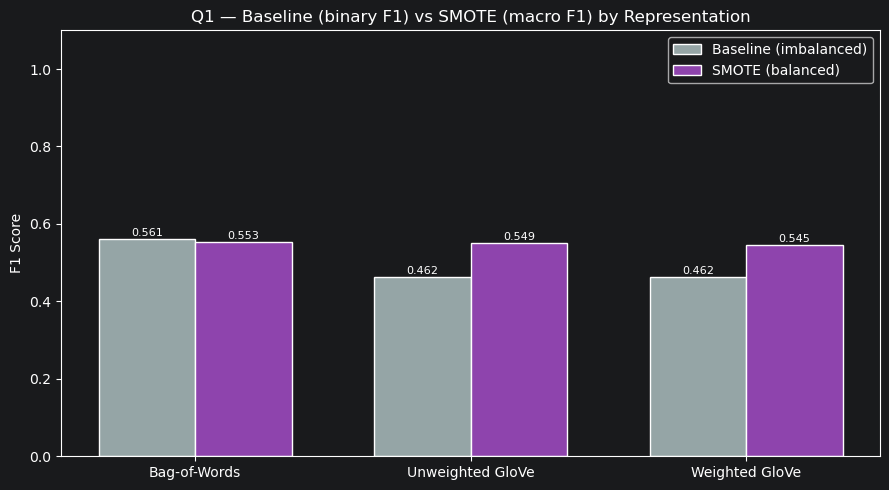

In [389]:
_f1_base_q1  = [_parse_mean(r["F1"]) for r in q1_results]
_f1_smote_q1 = [_parse_mean(r["F1"]) for r in q1_sm_results]
_reps        = [r["Representation"] for r in q1_results]
_x_rep       = np.arange(len(_reps))
_bw          = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
_b1 = ax.bar(_x_rep - _bw / 2, _f1_base_q1,  _bw, label="Baseline (imbalanced)",
             color="#95a5a6", edgecolor="white")
_b2 = ax.bar(_x_rep + _bw / 2, _f1_smote_q1, _bw, label="SMOTE (balanced)",
             color="#8e44ad", edgecolor="white")
for _bar, _val in zip(_b1, _f1_base_q1):
    ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.003,
            f"{_val:.3f}", ha="center", va="bottom", fontsize=8)
for _bar, _val in zip(_b2, _f1_smote_q1):
    ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.003,
            f"{_val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(_x_rep)
ax.set_xticklabels(_reps)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.1)
ax.set_title("Q1 — Baseline (binary F1) vs SMOTE (macro F1) by Representation")
ax.legend()
plt.tight_layout()
plt.show()


### Q2 (SMOTE) — Does Additional Context Improve Classification?
#
| Scenario | Input features |
|---|---|
| Text only | `review_text` (SMOTE-balanced, from Q1 above) |
| Text + Title | `review_text` + `review_title` (SMOTE applied to combined matrix) |
| Text + Title + Extra | above + `price`, `product_rating_count`, `brand_name` |
#
SMOTE is applied **after** concatenation so that the synthetic samples reflect the
joint feature space of the combined representation.


#### Scenario 2 (SMOTE) — Text + Title
#
| Column | BoW | Unweighted GloVe | Weighted GloVe |
|---|---|---|---|
| `review_text` | ✓ | ✓ | ✓ |
| `review_title` | ✓ | ✓ | ✓ |


In [390]:
_lr_q2_sm   = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)
_y_lbl      = df_count["is_a_buyer"].to_numpy()
q2_sm_results = []

print("Scenario 2 (SMOTE) — Text + Title\n")

# Pass original combined matrices — SMOTE runs inside each fold via ImbPipeline
_res = evaluate_representation_smote(_X_bow_q2, _y_lbl,
                                     "Bag-of-Words", "Logistic Regression", _lr_q2_sm)
_res["Information Setting"] = "Text + Title"
q2_sm_results.append(_res)

_res = evaluate_representation_smote(_X_unw_q2, _y_lbl,
                                     "Unweighted GloVe", "Logistic Regression", _lr_q2_sm)
_res["Information Setting"] = "Text + Title"
q2_sm_results.append(_res)

_res = evaluate_representation_smote(_X_wt_q2, _y_lbl,
                                     "Weighted GloVe", "Logistic Regression", _lr_q2_sm)
_res["Information Setting"] = "Text + Title"
q2_sm_results.append(_res)


Scenario 2 (SMOTE) — Text + Title

  Fold 1  |  Train: 47,865 samples (class 0: 9965, class 1: 37900)  →  after SMOTE: 75,800 (class 0: 37900, class 1: 37900)
         |  Test : 11,967 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 2  |  Train: 47,865 samples (class 0: 9964, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,967 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 3  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 4  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 5  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SM

#### Scenario 3 (SMOTE) — Text + Title + Extra
#
| Column | BoW | Unweighted GloVe | Weighted GloVe |
|---|---|---|---|
| `review_text` | ✓ | ✓ | ✓ |
| `review_title` | ✓ | ✓ | ✓ |
| `price` | scaled | scaled | scaled |
| `product_rating_count` | scaled | scaled | scaled |
| `brand_name` | OHE | OHE | OHE |


In [391]:
_lr_s3_sm = LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE)

print(f"Scenario 3 (SMOTE) — {_extra_label}\n")

# Pass original combined matrices — SMOTE runs inside each fold via ImbPipeline
_res = evaluate_representation_smote(_X_bow_s3, _y_lbl,
                                     "Bag-of-Words", "Logistic Regression", _lr_s3_sm)
_res["Information Setting"] = _extra_label
q2_sm_results.append(_res)

_res = evaluate_representation_smote(_X_unw_s3, _y_lbl,
                                     "Unweighted GloVe", "Logistic Regression", _lr_s3_sm)
_res["Information Setting"] = _extra_label
q2_sm_results.append(_res)

_res = evaluate_representation_smote(_X_wt_s3, _y_lbl,
                                     "Weighted GloVe", "Logistic Regression", _lr_s3_sm)
_res["Information Setting"] = _extra_label
q2_sm_results.append(_res)


Scenario 3 (SMOTE) — Text + Title + price + product_rating_count + brand_name

  Fold 1  |  Train: 47,865 samples (class 0: 9965, class 1: 37900)  →  after SMOTE: 75,800 (class 0: 37900, class 1: 37900)
         |  Test : 11,967 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 2  |  Train: 47,865 samples (class 0: 9964, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,967 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 3  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 4  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11,966 samples  ← ORIGINAL distribution (no SMOTE)
  Fold 5  |  Train: 47,866 samples (class 0: 9965, class 1: 37901)  →  after SMOTE: 75,802 (class 0: 37901, class 1: 37901)
         |  Test : 11

#### Q2 (SMOTE) — Scenario Comparison Chart


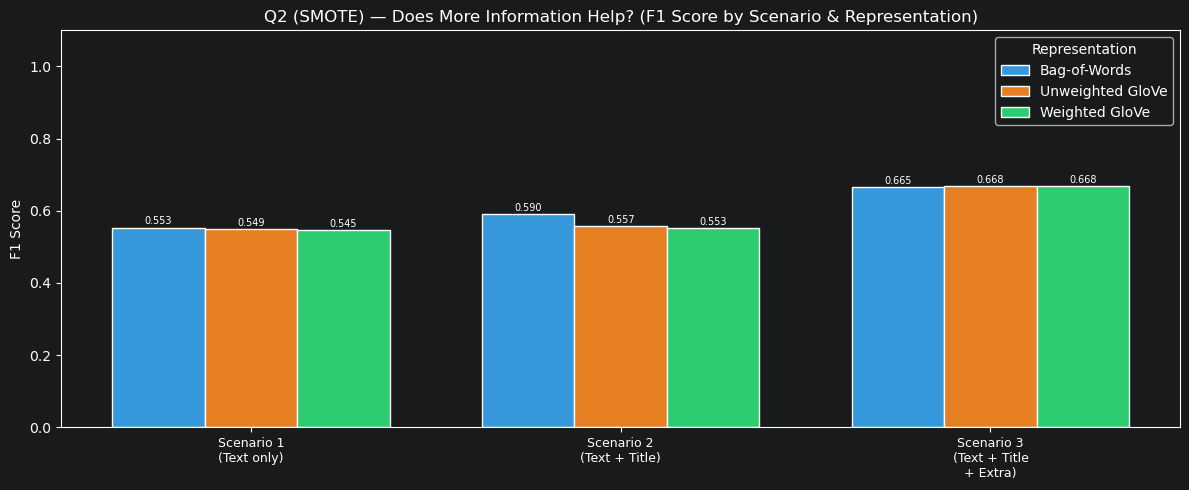

In [392]:
_sc1_sm = [{**r, "Information Setting": "Text only"} for r in q1_sm_results]
_all_sm_df = pd.DataFrame(_sc1_sm + q2_sm_results)
_all_sm_df["_f1_mean"] = _all_sm_df["F1"].apply(_parse_mean)

fig, ax = plt.subplots(figsize=(12, 5))
for _i, (_rep, _col) in enumerate(zip(_sc_reps, _sc_colors)):
    _vals = [
        _all_sm_df[
            (_all_sm_df["Information Setting"] == _sc) &
            (_all_sm_df["Representation"] == _rep)
        ]["_f1_mean"].values[0]
        for _sc in _sc_labels
    ]
    _bars = ax.bar(_sc_x + _i * _sc_width, _vals, _sc_width,
                   label=_rep, color=_col, edgecolor="white")
    for _bar, _val in zip(_bars, _vals):
        ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.003,
                f"{_val:.3f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(_sc_x + _sc_width)
ax.set_xticklabels(_sc_display, fontsize=9)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.1)
ax.set_title("Q2 (SMOTE) — Does More Information Help? (F1 Score by Scenario & Representation)")
ax.legend(title="Representation")
plt.tight_layout()
plt.show()


#### Q2 — Baseline vs SMOTE Comparison by Scenario & Representation


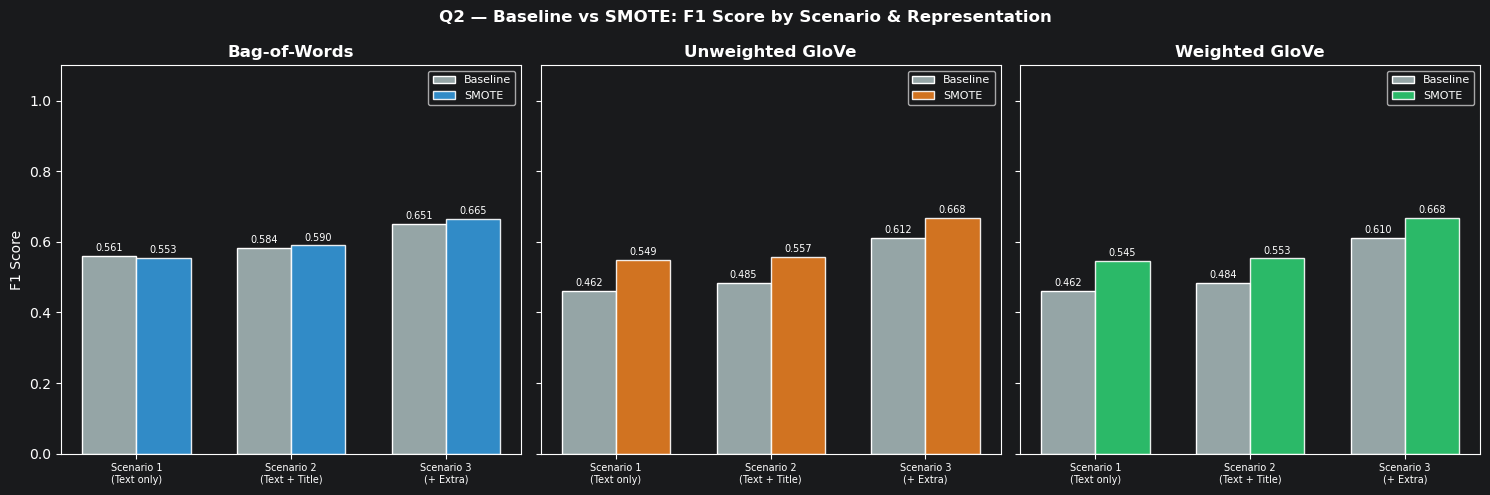

In [393]:
# One sub-plot per representation; each shows Baseline vs SMOTE across 3 scenarios
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for _ax, _rep, _col in zip(axes, _sc_reps, _sc_colors):
    _f1_base_sc = [
        _all_scenarios_df[
            (_all_scenarios_df["Information Setting"] == _sc) &
            (_all_scenarios_df["Representation"] == _rep)
        ]["_f1_mean"].values[0]
        for _sc in _sc_labels
    ]
    _f1_smote_sc = [
        _all_sm_df[
            (_all_sm_df["Information Setting"] == _sc) &
            (_all_sm_df["Representation"] == _rep)
        ]["_f1_mean"].values[0]
        for _sc in _sc_labels
    ]
    _x_sc = np.arange(3)
    _bw   = 0.35
    _b1 = _ax.bar(_x_sc - _bw / 2, _f1_base_sc,  _bw, label="Baseline",
                  color="#95a5a6", edgecolor="white")
    _b2 = _ax.bar(_x_sc + _bw / 2, _f1_smote_sc, _bw, label="SMOTE",
                  color=_col, edgecolor="white", alpha=0.9)
    for _bar, _val in zip(_b1, _f1_base_sc):
        _ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.008,
                 f"{_val:.3f}", ha="center", va="bottom", fontsize=7)
    for _bar, _val in zip(_b2, _f1_smote_sc):
        _ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.008,
                 f"{_val:.3f}", ha="center", va="bottom", fontsize=7)
    _ax.set_title(_rep, fontweight="bold")
    _ax.set_xticks(_x_sc)
    _ax.set_xticklabels(["Scenario 1\n(Text only)",
                         "Scenario 2\n(Text + Title)",
                         "Scenario 3\n(+ Extra)"], fontsize=7)
    _ax.set_ylim(0, 1.1)
    _ax.legend(fontsize=8)

axes[0].set_ylabel("F1 Score")
plt.suptitle("Q2 — Baseline vs SMOTE: F1 Score by Scenario & Representation",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
